In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import os
import json

# loading files
data_path = "/home/harshil/IV-Surface-Reconstruction/iv_csv/"
files = os.listdir(data_path)
print("Available files:")
for f in files:
    print(f"  - {f}")

# joinig all dataframes
dfs = []
for file in files:
    if file.endswith(".csv"):
        temp_df = pd.read_csv(data_path + file)
        print(f"Loaded {file}: {len(temp_df)} rows")
        dfs.append(temp_df)


df = pd.concat(dfs, ignore_index=True)

print("\n" + "=" * 50)
print(f"TOTAL COMBINED DATA: {len(df)} rows")
print("=" * 50)
print("\nData Preview:")
print(df.head())
print("\nColumns:")
print(df.columns.tolist())
print("\nDate range:")
print(f"  From: {df['date'].min()}")
print(f"  To: {df['date'].max()}")
print("\nData types:")
print(df.dtypes)

Available files:
  - predicted_iv22.csv
  - predicted_iv19.csv
  - predicted_iv24.csv
  - predicted_iv23.csv
  - predicted_iv21.csv
  - predicted_iv20.csv
Loaded predicted_iv22.csv: 38654 rows
Loaded predicted_iv19.csv: 38654 rows
Loaded predicted_iv24.csv: 38808 rows
Loaded predicted_iv23.csv: 38500 rows
Loaded predicted_iv21.csv: 38808 rows
Loaded predicted_iv20.csv: 38808 rows

TOTAL COMBINED DATA: 232232 rows

Data Preview:
         date       tau         m        IV
0  2022-01-03  0.027397 -0.510826  0.339855
1  2022-01-03  0.027397 -0.223144  0.265239
2  2022-01-03  0.027397 -0.105361  0.252733
3  2022-01-03  0.027397 -0.051293  0.250502
4  2022-01-03  0.027397 -0.025318  0.250216

Columns:
['date', 'tau', 'm', 'IV']

Date range:
  From: 2019-01-02
  To: 2024-12-31

Data types:
date     object
tau     float64
m       float64
IV      float64
dtype: object


In [2]:
df["k"] = df["m"]
df["T"] = df["tau"] * 365

print("Data summary:")
print(f"  Moneyness (k) range: [{df['k'].min():.3f}, {df['k'].max():.3f}]")
print(f"  Maturity (T) range: [{df['T'].min():.1f}, {df['T'].max():.1f}] days")
print(f"  IV range: [{df['IV'].min():.3f}, {df['IV'].max():.3f}]")

# defining domain boundaries
k_min, k_max = -0.5, 0.5
T_min, T_max = 7, 365

# Filter data within domain (gpt'd)
df_filtered = df[
    (df["k"] >= k_min) & (df["k"] <= k_max) & (df["T"] >= T_min) & (df["T"] <= T_max)
].copy()

print(f"\nOriginal data points: {len(df)}")
print(f"Filtered data points: {len(df_filtered)}")

# making uniform grid for ease, ig can be changed as per need
N = 64  # moneyness dimension
M = 64  # time dimension

k_grid = np.linspace(k_min, k_max, N)
T_grid = np.linspace(T_min, T_max, M)

# mesh grid
K_mesh, T_mesh = np.meshgrid(k_grid, T_grid)

print(f"\nGrid created: {N} × {M} = {N*M} points")
print(f"k range: [{k_min}, {k_max}]")
print(f"T range: [{T_min}, {T_max}] days")

Data summary:
  Moneyness (k) range: [-0.511, 0.693]
  Maturity (T) range: [10.0, 730.0] days
  IV range: [0.010, 1.003]

Original data points: 232232
Filtered data points: 149292

Grid created: 64 × 64 = 4096 points
k range: [-0.5, 0.5]
T range: [7, 365] days


In [3]:
# interpolation
k_obs = df_filtered["k"].values
T_obs = df_filtered["T"].values
IV_obs = df_filtered["IV"].values

print(f"Observed IV range: [{IV_obs.min():.4f}, {IV_obs.max():.4f}]")

# Linear interpolation for initial grid
IV_grid = griddata(
    points=(k_obs, T_obs),
    values=IV_obs,
    xi=(K_mesh, T_mesh),
    method="linear",
    fill_value=np.nan,
)

# Generate binary mask
mask = ~np.isnan(IV_grid)
mask = mask.astype(int)

print(f"\nMask statistics:")
print(f"  Observed points (1): {mask.sum()} ({100*mask.sum()/(N*M):.1f}%)")
print(f"  Missing points (0): {(1-mask).sum()} ({100*(1-mask).sum()/(N*M):.1f}%)")

# Fill missing values using nearest neighbor
if np.isnan(IV_grid).any():
    print("\nFilling missing values with nearest neighbor interpolation...")
    IV_grid_filled = griddata(
        points=(k_obs, T_obs), values=IV_obs, xi=(K_mesh, T_mesh), method="nearest"
    )
    IV_grid = np.where(np.isnan(IV_grid), IV_grid_filled, IV_grid)

print(f"Remaining NaN values: {np.isnan(IV_grid).sum()}")

# converting  IV into total variance (suggested by chatgpt)
variance_grid = (IV_grid**2) * (T_mesh / 365)

print(f"\nVariance grid range: [{variance_grid.min():.4f}, {variance_grid.max():.4f}]")

Observed IV range: [0.0329, 0.7926]



Mask statistics:
  Observed points (1): 2520 (61.5%)
  Missing points (0): 1576 (38.5%)

Filling missing values with nearest neighbor interpolation...


Remaining NaN values: 0

Variance grid range: [0.0006, 0.0760]


In [4]:
# normalisation and splitting
print("Applying min-max normalization...")
IV_min = IV_grid.min()
IV_max = IV_grid.max()
IV_normalized = (IV_grid - IV_min) / (IV_max - IV_min)

print(f"Normalized IV range: [{IV_normalized.min():.4f}, {IV_normalized.max():.4f}]")

# Split by calendar time (train/val/test) - 70/15/15 split
df_filtered["date"] = pd.to_datetime(df_filtered["date"])
dates = sorted(df_filtered["date"].unique())

train_split = int(0.7 * len(dates))
val_split = int(0.85 * len(dates))

train_dates = dates[:train_split]
val_dates = dates[train_split:val_split]
test_dates = dates[val_split:]

print(f"\nCalendar time split:")
print(f"  Train: {len(train_dates)} dates ({train_dates[0]} to {train_dates[-1]})")
print(f"  Val:   {len(val_dates)} dates ({val_dates[0]} to {val_dates[-1]})")
print(f"  Test:  {len(test_dates)} dates ({test_dates[0]} to {test_dates[-1]})")

Applying min-max normalization...
Normalized IV range: [0.0000, 1.0000]

Calendar time split:
  Train: 1055 dates (2019-01-02 00:00:00 to 2023-03-14 00:00:00)
  Val:   226 dates (2023-03-15 00:00:00 to 2024-02-06 00:00:00)
  Test:  227 dates (2024-02-07 00:00:00 to 2024-12-31 00:00:00)


In [5]:
print("=" * 50)
print("SAVING DELIVERABLES")
print("=" * 50)

output_dir = "/home/harshil/IV-Surface-Reconstruction/"


np.save(output_dir + "x.npy", IV_normalized)
print("✓ Saved: x.npy (normalized IV grid)")

np.save(output_dir + "mask.npy", mask)
print("✓ Saved: mask.npy (binary mask)")


np.save(output_dir + "variance.npy", variance_grid)
print("✓ Saved: variance.npy (total variance grid)")


metadata = {
    "k_min": float(k_min),
    "k_max": float(k_max),
    "T_min": float(T_min),
    "T_max": float(T_max),
    "grid_size": [N, M],
    "normalization_method": "min-max",
    "IV_min": float(IV_min),
    "IV_max": float(IV_max),
    "observed_points": int(mask.sum()),
    "total_points": int(N * M),
    "train_dates": [str(d.date()) for d in train_dates],
    "val_dates": [str(d.date()) for d in val_dates],
    "test_dates": [str(d.date()) for d in test_dates],
}

with open(output_dir + "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("✓ Saved: metadata.json")

print("\n" + "=" * 50)
print("✅ PHASE 1 COMPLETE!")
print("=" * 50)
print("\nFiles saved")
print("Download them from the output panel on the right →")

SAVING DELIVERABLES
✓ Saved: x.npy (normalized IV grid)
✓ Saved: mask.npy (binary mask)
✓ Saved: variance.npy (total variance grid)
✓ Saved: metadata.json

✅ PHASE 1 COMPLETE!

Files saved
Download them from the output panel on the right →


In [6]:
import matplotlib.pyplot as plt

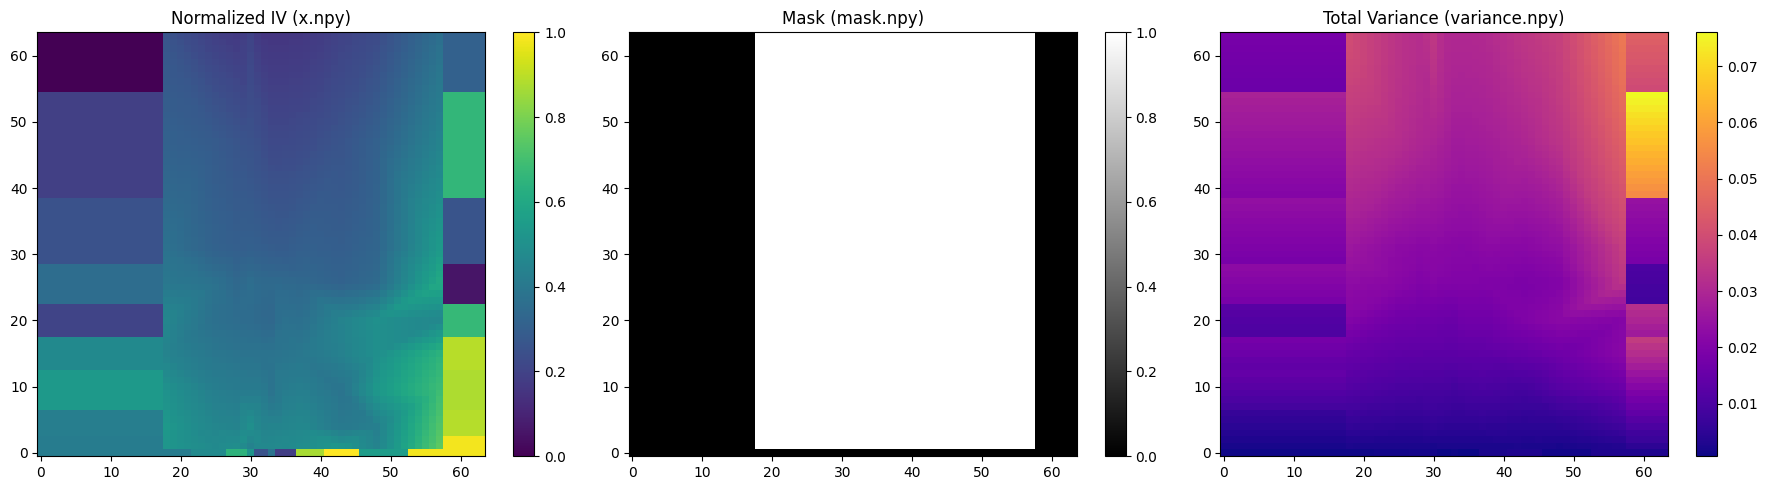

In [7]:
import numpy as np

# Load the saved npy files
output_dir = "/home/harshil/IV-Surface-Reconstruction/"
x = np.load(output_dir + "x.npy")
mask = np.load(output_dir + "mask.npy")
variance = np.load(output_dir + "variance.npy")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Normalized IV
im1 = axes[0].imshow(x, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('Normalized IV (x.npy)')
fig.colorbar(im1, ax=axes[0])

# Plot Mask
im2 = axes[1].imshow(mask, aspect='auto', origin='lower', cmap='gray')
axes[1].set_title('Mask (mask.npy)')
fig.colorbar(im2, ax=axes[1])

# Plot Total Variance
im3 = axes[2].imshow(variance, aspect='auto', origin='lower', cmap='plasma')
axes[2].set_title('Total Variance (variance.npy)')
fig.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()